# Analisis de los resultados

In [1]:
base = "/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras"
path_guardado = base + "/analisis"

## Inventory

In [2]:
import os

experiment = "2" # 1 2

path_dwa=base +f"/results_dwa{experiment}"
path_coursera=base +f"/results_coursera{experiment}"

In [3]:
# ============================================================
# Inventario de artefactos AI4LABOUR (DWA vs Coursera)
# Reglas:
#  - TP/FP/FN: files "errors_tp*.csv", "errors_fp*.csv", "errors_fn*.csv"
#  - Plots: *.png / *.svg
#  - ranking_summary_*.csv, threshold_Sweep_*.csv (case-insensitive), neighbors_all_long_*.csv
#  - Sufijos estrictos: *_dwa / *_coursera (antes de la extensión)
# Salidas: CSVs en path_guardado
# ============================================================

import os, re, pandas as pd
from pathlib import Path
from datetime import datetime

# --- Helpers ---

def _classify_artifact(relpath: str, basename: str, ext: str) -> str:
    """Clasifica el artefacto según las reglas acordadas."""
    lowp = relpath.lower()
    base = basename.lower()
    ext = ext.lower()

    # Plots por extensión
    if ext in (".png", ".svg"):
        return "plots"

    # Winner
    if re.search(r"\bwinner.*\.txt$", base):
        return "winner"

    # Ranking summary con guion bajo
    if re.search(r"ranking_summary_.*\.csv$", base, re.IGNORECASE):
        return "ranking_summary"

    # Threshold sweep (threshold_Sweep_… o threshold_sweep_…) con guion bajo
    if re.search(r"threshold[_\-]?sweep_.*\.csv$", base, re.IGNORECASE):
        return "threshold_sweep"

    # Best thresholds (si existe)
    if re.search(r"best[_\-]?thresholds_.*\.csv$", base, re.IGNORECASE):
        return "best_thresholds"

    # Near-threshold
    if re.search(r"near[_\-]?threshold.*\.csv$", base, re.IGNORECASE):
        return "near_threshold"

    # TP / FP / FN con prefijo errors_
    m_err = re.search(r"^errors_(tp|fp|fn)(?:_.*)?\.csv$", base)
    if m_err:
        return m_err.group(1)

    # Fallback legacy TP/FP/FN (por si cuela)
    m_legacy = re.search(r"(^|/)((tp|fp|fn)(?:_.*)?)\.csv$", lowp)
    if m_legacy:
        return m_legacy.group(3)

    # Neighbors all_long con guion bajo tras all_long
    if re.search(r"neighbors.*all_long_.*\.csv$", base, re.IGNORECASE):
        return "neighbors_all_long"

    # Neighbors (corto) con guion bajo
    if re.search(r"^neighbors_.*\.csv$", base, re.IGNORECASE):
        return "neighbors"

    # Otros CSV
    if ext == ".csv":
        return "csv_other"

    return "other"


def _detect_pipeline_tag(basename: str) -> str:
    """Detecta tag de pipeline en el nombre."""
    b = basename.lower()
    if "_dwa" in b:
        return "_dwa"
    if "_coursera" in b:
        return "_coursera"
    return "unknown"


def _suffix_present_strict(basename: str, expected_suffix: str) -> bool:
    """Comprueba si el nombre (sin extensión) TERMINA exactamente en el sufijo esperado."""
    stem, _ = os.path.splitext(basename)
    return stem.lower().endswith(expected_suffix)


def scan_directory(root_dir: str, expected_suffix: str) -> pd.DataFrame:
    """
    Recorre recursivamente una carpeta y construye el inventario de artefactos,
    incluyendo clasificación, chequeos de sufijo y tag.
    """
    rows = []
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"No existe la ruta: {root_dir}")

    for p in root.rglob("*"):
        if p.is_dir():
            continue
        rel = str(p.relative_to(root))
        base = p.name
        ext = p.suffix
        size = p.stat().st_size
        mtime = datetime.fromtimestamp(p.stat().st_mtime)

        artifact = _classify_artifact(rel, base, ext)
        pipeline_tag_in_name = _detect_pipeline_tag(base)

        # Tipos donde exigimos sufijo *_dwa / *_coursera
        suffix_applicable = artifact in {
            "ranking_summary", "threshold_sweep", "best_thresholds",
            "neighbors", "neighbors_all_long"
        }
        suffix_present = _suffix_present_strict(base, expected_suffix) if suffix_applicable else None
        pipeline_tag_mismatch = (
            pipeline_tag_in_name != "unknown"
            and pipeline_tag_in_name != expected_suffix
        )

        rows.append({
            "container": root.name,
            "source": "dir",
            "path_rel": rel,
            "basename": base,
            "ext": ext.lower(),
            "size_bytes": size,
            "size_kb": round(size/1024, 1),
            "modified": mtime.isoformat(timespec="seconds"),
            "artifact_type": artifact,
            "pipeline_expected": expected_suffix,
            "pipeline_tag_in_name": pipeline_tag_in_name,
            "suffix_applicable": suffix_applicable,
            "suffix_expected": expected_suffix,
            "suffix_present": suffix_present,
            "pipeline_tag_mismatch": pipeline_tag_mismatch,
            "abs_path": str(p),
        })
    return pd.DataFrame(rows)


def parse_winners(df_dir: pd.DataFrame) -> pd.DataFrame:
    """
    Extrae y parsea cualquier 'winner*.txt' del inventario.
    Formato esperado: pares clave=valor por línea (tolerante).
    """
    winners = df_dir[df_dir["artifact_type"] == "winner"].copy()
    out = []
    for _, r in winners.iterrows():
        try:
            with open(r["abs_path"], "r", encoding="utf-8") as f:
                content = f.read()
        except Exception:
            content = ""

        meta = {"MODEL": None, "PRESET": None, "nDCG@10": None,
                "MAP@10": None, "R@1": None, "MRR": None, "THRESHOLD": None}
        for line in content.splitlines():
            # Acepta "KEY=VAL" o "KEY: VAL"
            m_eq = re.match(r"\s*([^:=\s]+)\s*[:=]\s*(.+?)\s*$", line)
            if m_eq:
                k, v = m_eq.group(1), m_eq.group(2)
                if k in meta:
                    meta[k] = v

        out.append({
            "pipeline_expected": r["pipeline_expected"],
            "basename": r["basename"],
            "path_rel": r["path_rel"],
            "abs_path": r["abs_path"],
            **meta
        })
    return pd.DataFrame(out)


def suffix_stats(df: pd.DataFrame) -> tuple[int, int, float]:
    """Devuelve (#ok, #aplicables, %) de cumplimiento de sufijo."""
    sub = df[df["suffix_applicable"]]
    if sub.empty:
        return (0, 0, 0.0)
    ok = sub["suffix_present"].fillna(False).sum()
    tot = len(sub)
    return int(ok), int(tot), round(100.0*ok/tot, 1)



In [4]:

# --- Pipeline ---
path_inventory = path_guardado + "/inventory"
Path(path_inventory).mkdir(parents=True, exist_ok=True)

dwa_df = scan_directory(path_dwa, expected_suffix="_dwa")
cour_df = scan_directory(path_coursera, expected_suffix="_coursera")


In [5]:
display(dwa_df)
display(cour_df)

,container,source,path_rel,basename,ext,size_bytes,size_kb,modified,artifact_type,pipeline_expected,pipeline_tag_in_name,suffix_applicable,suffix_expected,suffix_present,pipeline_tag_mismatch,abs_path
0,results_dwa2,dir,neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mej...,neighbors_home_jovyan_Joel_Pardo_AI4LABOUR_Mej...,.csv,280776,274.2,2025-09-17T14:32:26,neighbors,_dwa,_coursera,True,_dwa,False,True,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
1,results_dwa2,dir,neighbors_sentence_transformers_all_mpnet_base...,neighbors_sentence_transformers_all_mpnet_base...,.csv,276723,270.2,2025-09-17T14:31:58,neighbors,_dwa,unknown,True,_dwa,False,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
2,results_dwa2,dir,neighbors_embedding_data_deberta_sentence_tran...,neighbors_embedding_data_deberta_sentence_tran...,.csv,256172,250.2,2025-09-17T14:31:38,neighbors,_dwa,unknown,True,_dwa,False,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
3,results_dwa2,dir,neighbors_sentence_transformers_distiluse_base...,neighbors_sentence_transformers_distiluse_base...,.csv,267202,260.9,2025-09-17T14:30:54,neighbors,_dwa,unknown,True,_dwa,False,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
4,results_dwa2,dir,near_threshold.csv,near_threshold.csv,.csv,3704,3.6,2025-09-17T14:33:02,near_threshold,_dwa,unknown,False,_dwa,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,results_dwa2,dir,models/.DS_Store,.DS_Store,,6148,6.0,2025-09-17T16:36:00,other,_dwa,unknown,False,_dwa,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
150,results_dwa2,dir,models/tsdae/google-bert/bert-base-uncased/voc...,vocab.txt,.txt,231508,226.1,2025-09-17T14:27:56,other,_dwa,unknown,False,_dwa,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
151,results_dwa2,dir,models/simcse_coursera_hard/sentence-transform...,vocab.txt,.txt,231508,226.1,2025-09-17T14:27:38,other,_dwa,unknown,False,_dwa,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
152,results_dwa2,dir,models/simcse_coursera_sup/sentence-transforme...,vocab.txt,.txt,231508,226.1,2025-09-17T14:27:40,other,_dwa,unknown,False,_dwa,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...


,container,source,path_rel,basename,ext,size_bytes,size_kb,modified,artifact_type,pipeline_expected,pipeline_tag_in_name,suffix_applicable,suffix_expected,suffix_present,pipeline_tag_mismatch,abs_path
0,results_coursera2,dir,neighbors_coursera_long_sentence_transformers_...,neighbors_coursera_long_sentence_transformers_...,.csv,527354,515.0,2025-09-17T15:18:20,neighbors,_coursera,_dwa,True,_coursera,False,True,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
1,results_coursera2,dir,neighbors_coursera_long_home_jovyan_Joel_Pardo...,neighbors_coursera_long_home_jovyan_Joel_Pardo...,.csv,682082,666.1,2025-09-17T15:35:42,neighbors,_coursera,_dwa,True,_coursera,False,True,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
2,results_coursera2,dir,neighbors_coursera_long_sentence_transformers_...,neighbors_coursera_long_sentence_transformers_...,.csv,532592,520.1,2025-09-17T15:22:40,neighbors,_coursera,_dwa,True,_coursera,False,True,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
3,results_coursera2,dir,neighbors_coursera_long_home_jovyan_Joel_Pardo...,neighbors_coursera_long_home_jovyan_Joel_Pardo...,.csv,697790,681.4,2025-09-17T15:36:12,neighbors,_coursera,_dwa,True,_coursera,False,True,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
4,results_coursera2,dir,near_threshold.csv,near_threshold.csv,.csv,19263,18.8,2025-09-17T15:36:24,near_threshold,_coursera,unknown,False,_coursera,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,results_coursera2,dir,models/.DS_Store,.DS_Store,,6148,6.0,2025-09-17T17:40:11,other,_coursera,unknown,False,_coursera,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
149,results_coursera2,dir,models/tsdae_coursera/google-bert/bert-base-un...,vocab.txt,.txt,231508,226.1,2025-09-17T15:12:12,other,_coursera,unknown,False,_coursera,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
150,results_coursera2,dir,models/simcse_coursera_hard/sentence-transform...,vocab.txt,.txt,231508,226.1,2025-09-17T15:11:50,other,_coursera,unknown,False,_coursera,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...
151,results_coursera2,dir,models/simcse_coursera_sup/sentence-transforme...,vocab.txt,.txt,231508,226.1,2025-09-17T15:11:54,other,_coursera,unknown,False,_coursera,None,False,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...


La forma en la que guardamos los resultados no es univoca. Tenemos que para coursera, muchos se guardan con el sufijo _coursera. Esta ultima celda era simplemente para comprobar que archivos tienen esa nomenclatura y que no, de cuando son y si hay archivos antiguos obsoletos o simplemente duplicados. y como vemos, no los hay. 

In [6]:

# Winners (si existen dentro de los folders)
winners_dwa = parse_winners(dwa_df)
winners_cour = parse_winners(cour_df)
winners_all = pd.concat([winners_dwa, winners_cour], ignore_index=True) if not winners_dwa.empty or not winners_cour.empty else pd.DataFrame()


In [7]:
display(winners_all)

,pipeline_expected,basename,path_rel,abs_path,MODEL,PRESET,nDCG@10,MAP@10,R@1,MRR,THRESHOLD
0,_dwa,winner.txt,winner.txt,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,E_diversity,0.6310,0.4376,0.1795,0.5693,1.290044
1,_coursera,winner.txt,winner.txt,/Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejo...,sentence-transformers/paraphrase-MiniLM-L3-v2,E_diversity,0.2597,0.1924,0.1047,0.2890,1.000000


Aqui tenemos los modelos ganadores para cada uno de los notebooks. Para coursera tenemos que el mejor performa es el simcse_base configuracion F_recall. Para dwa el mejor es es distilroberta de sentence-transformers configuracion H_zfilter. 

In [8]:

# Resumen comparativo por tipo
expected_types = ["ranking_summary","threshold_sweep","best_thresholds",
                  "neighbors_all_long","neighbors","winner","tp","fp","fn","near_threshold","plots"]

def summarize(df: pd.DataFrame, label: str) -> pd.Series:
    s = df.groupby("artifact_type").size().rename(f"count_{label}")
    return s.reindex(expected_types, fill_value=0)

sum_dwa = summarize(dwa_df, "dwa")
sum_cour = summarize(cour_df, "coursera")
summary = pd.concat([sum_dwa, sum_cour], axis=1).reset_index().rename(columns={"index":"artifact_type"})
summary["missing_in_dwa"] = summary["count_dwa"] == 0
summary["missing_in_coursera"] = summary["count_coursera"] == 0


In [9]:
display(sum_dwa)
display(sum_cour)

artifact_type
ranking_summary         1
threshold_sweep         1
best_thresholds         1
neighbors_all_long      1
neighbors             120
winner                  1
tp                      1
fp                      1
fn                      1
near_threshold          1
plots                  19
Name: count_dwa, dtype: int64

artifact_type
ranking_summary         1
threshold_sweep         1
best_thresholds         1
neighbors_all_long      1
neighbors             120
winner                  1
tp                      1
fp                      1
fn                      1
near_threshold          1
plots                  18
Name: count_coursera, dtype: int64

Vemos una diferencia de un grafico. Parece ser que es el que estaba corrupto en H4. 

In [10]:

# Cumplimiento de sufijo y mismatches
dwa_ok, dwa_tot, dwa_pct = suffix_stats(dwa_df)
cour_ok, cour_tot, cour_pct = suffix_stats(cour_df)

compliance = pd.DataFrame([
    {
        "folder": Path(path_dwa).name,
        "suffix_expected": "_dwa",
        "applicable_files": dwa_tot,
        "suffix_ok": dwa_ok,
        "suffix_ok_%": dwa_pct,
        "pipeline_tag_mismatches": int(dwa_df["pipeline_tag_mismatch"].sum()),
    },
    {
        "folder": Path(path_coursera).name,
        "suffix_expected": "_coursera",
        "applicable_files": cour_tot,
        "suffix_ok": cour_ok,
        "suffix_ok_%": cour_pct,
        "pipeline_tag_mismatches": int(cour_df["pipeline_tag_mismatch"].sum()),
    },
])


In [11]:
display(compliance)

,folder,suffix_expected,applicable_files,suffix_ok,suffix_ok_%,pipeline_tag_mismatches
0,results_dwa2,_dwa,124,0,0.0,30
1,results_coursera2,_coursera,124,0,0.0,124


En cuanto a la consistencia que nos referiamos antes, parece ser que hay mismatches por que se en coursera se guardan como _coursera_dwa. Como el porcentaje de suffix esta 0 significa que los lectores no pierden ficheros por culpa del discriminante (_dwa o _coursra).

In [12]:

# Artefactos clave ausentes
KEY_TYPES = ["ranking_summary","threshold_sweep","best_thresholds","neighbors_all_long","winner"]
missing_rows = []
for t in KEY_TYPES:
    if summary.loc[summary["artifact_type"]==t, "count_dwa"].values[0] == 0:
        missing_rows.append({"pipeline":"_dwa","artifact_type":t,"status":"missing"})
    if summary.loc[summary["artifact_type"]==t, "count_coursera"].values[0] == 0:
        missing_rows.append({"pipeline":"_coursera","artifact_type":t,"status":"missing"})
missing_df = pd.DataFrame(missing_rows)


In [13]:
display(missing_df)

""


Esto significa, como hemos visto antes, que no hay ningun archivo que falte en los dos pipelines. 

In [14]:

# --- Guardar CSVs ---
out_summary = os.path.join(path_inventory, f"inventory_summary{experiment}.csv")
out_dwa = os.path.join(path_inventory, f"inventory_details_dwa{experiment}.csv")
out_cour = os.path.join(path_inventory, f"inventory_details_coursera{experiment}.csv")
out_compliance = os.path.join(path_inventory, f"inventory_compliance{experiment}.csv")
out_missing = os.path.join(path_inventory, f"inventory_missing_key{experiment}.csv")
out_winners = os.path.join(path_inventory, f"inventory_winners{experiment}.csv")

summary.to_csv(out_summary, index=False)
dwa_df.sort_values(["artifact_type","basename"]).to_csv(out_dwa, index=False)
cour_df.sort_values(["artifact_type","basename"]).to_csv(out_cour, index=False)
compliance.to_csv(out_compliance, index=False)
(missing_df if not missing_df.empty else pd.DataFrame([{"status":"All key artifact types present in both pipelines."}])).to_csv(out_missing, index=False)
if not winners_all.empty:
    winners_all.to_csv(out_winners, index=False)

print("Inventario generado ✅")
print(f"- Resumen comparativo   → {out_summary}")
print(f"- DWA detalles          → {out_dwa}")
print(f"- Coursera detalles     → {out_cour}")
print(f"- Cumplimiento sufijos  → {out_compliance}")
print(f"- Faltantes clave       → {out_missing}")
if not winners_all.empty:
    print(f"- Winners parseados     → {out_winners}")


Inventario generado ✅
- Resumen comparativo   → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_summary2.csv
- DWA detalles          → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_details_dwa2.csv
- Coursera detalles     → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_details_coursera2.csv
- Cumplimiento sufijos  → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_compliance2.csv
- Faltantes clave       → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_missing_key2.csv
- Winners parseados     → /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/inventory/inventory_winners2.csv


## Key tables

In [15]:
import os, re, io, zipfile, pandas as pd
from pathlib import Path
from datetime import datetime

# -----------------------
# CONFIG — AJUSTA AQUÍ (tus rutas locales)
# -----------------------
path_keytables = os.path.join(path_guardado, "key_tables")
path_neighbors = os.path.join(path_keytables, "neighbors_all")
path_ranking   = os.path.join(path_keytables, "ranking_summary")
path_threshold = os.path.join(path_keytables, "threshold_sweep")

for p in [path_keytables, path_neighbors, path_ranking, path_threshold]:
    os.makedirs(p, exist_ok=True)


In [16]:

# -----------------------
# Helpers
# -----------------------
def list_files_in_container(container_path: str):
    out = []
    root = Path(container_path)
    for p in root.rglob("*"):
        if p.is_dir(): 
            continue
        rel = str(p.relative_to(root))
        info = {"size": p.stat().st_size, "mtime": datetime.fromtimestamp(p.stat().st_mtime), "abs_path": str(p)}
        out.append((container_path, False, rel, os.path.basename(p), None, info))
    return out

def classify_artifact(basename: str) -> str:
    b = basename.lower()
    if re.search(r"^ranking_summary_.*\.csv$", b, flags=re.IGNORECASE):
        return "ranking_summary"
    if re.search(r"^threshold[_\-]?sweep_.*\.csv$", b, flags=re.IGNORECASE):
        return "threshold_sweep"
    if re.search(r"neighbors.*all_long_.*\.csv$", b, flags=re.IGNORECASE):
        return "neighbors_all_long"
    return "other"

def infer_pipeline(container_path: str, basename: str) -> str:
    """
    Para Coursera, aceptamos nombres que contengan _coursera o _coursera_dwa,
    pero la carpeta manda (si viene de results_coursera*, lo etiquetamos 'coursera').
    """
    cl = container_path.lower()
    b = basename.lower()
    if "coursera" in cl:
        return "coursera"
    if "dwa" in cl:
        return "dwa"
    if "_coursera" in b or "_coursera_dwa" in b:
        return "coursera"
    if "_dwa" in b:
        return "dwa"
    return "unknown"


In [17]:

# -----------------------
# Scan & read
# -----------------------
containers = []
if os.path.isdir(path_dwa): containers.append(path_dwa)
if os.path.isdir(path_coursera): containers.append(path_coursera)

rows_index = []
dfs_neighbors, dfs_ranking, dfs_threshold = [], [], []

for cont in containers:
    for container_path, is_zip, rel_path, base, reader, info in list_files_in_container(cont):
        a_type = classify_artifact(base)
        if a_type not in {"neighbors_all_long", "ranking_summary", "threshold_sweep"}:
            continue
        pipeline = infer_pipeline(container_path, base)
        try:
            df = pd.read_csv(info["abs_path"])  # leyendo de carpeta
        except Exception as e:
            rows_index.append({
                "container": os.path.basename(container_path),
                "pipeline": pipeline,
                "artifact_type": a_type,
                "basename": base,
                "rel_path": rel_path,
                "status": f"READ_ERROR: {e}",
                "n_rows": None,
                "n_cols": None,
                "mtime": info["mtime"],
                "size_bytes": info["size"],
            })
            continue

        df["_source_container"] = os.path.basename(container_path)
        df["_source_pipeline"]  = pipeline
        df["_source_artifact"]  = a_type
        df["_source_basename"]  = base
        df["_source_relpath"]   = rel_path
        df["_source_mtime"]     = info["mtime"]

        if a_type == "neighbors_all_long":
            dfs_neighbors.append(df)
        elif a_type == "ranking_summary":
            dfs_ranking.append(df)
        elif a_type == "threshold_sweep":
            dfs_threshold.append(df)

        rows_index.append({
            "container": os.path.basename(container_path),
            "pipeline": pipeline,
            "artifact_type": a_type,
            "basename": base,
            "rel_path": rel_path,
            "status": "OK",
            "n_rows": len(df),
            "n_cols": len(df.columns),
            "mtime": info["mtime"],
            "size_bytes": info["size"],
        })


In [18]:

index_df = pd.DataFrame(rows_index).sort_values(["artifact_type","pipeline","container","basename"]).reset_index(drop=True)
index_df.to_csv(os.path.join(path_keytables, f"key_tables_manifest{experiment}.csv"), index=False)

display(index_df)


,container,pipeline,artifact_type,basename,rel_path,status,n_rows,n_cols,mtime,size_bytes
0,results_coursera2,coursera,neighbors_all_long,neighbors_coursera_all_long_dwa_cb25d773_skill...,neighbors_coursera_all_long_dwa_cb25d773_skill...,OK,265200,21,2025-09-17 15:36:16,71957795
1,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,OK,265153,21,2025-09-17 14:33:00,70356063
2,results_coursera2,coursera,ranking_summary,ranking_summary_coursera_dwa_cb25d773_skill_1e...,ranking_summary_coursera_dwa_cb25d773_skill_1e...,OK,480,18,2025-09-17 15:36:22,111196
3,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,OK,480,18,2025-09-17 14:33:02,107783
4,results_coursera2,coursera,threshold_sweep,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,OK,4920,14,2025-09-17 15:36:24,729693
5,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,OK,10920,16,2025-09-17 14:33:02,1969625


In [19]:

# -----------------------
# Save consolidated tables
# -----------------------
if dfs_neighbors:
    neigh_all = pd.concat(dfs_neighbors, ignore_index=True, sort=False)
    neigh_all.to_csv(os.path.join(path_neighbors, f"neighbors_all_long__ALL{experiment}.csv"), index=False)
    for pip in ["dwa","coursera","unknown"]:
        sub = neigh_all[neigh_all["_source_pipeline"]==pip]
        if not sub.empty:
            sub.to_csv(os.path.join(path_neighbors, f"neighbors_all_long__{pip}_{experiment}.csv"), index=False)

display(neigh_all)

,model,preset,q_idx,q_label,q_text,rank,cand_idx,cand_label,sim,z,...,lenpen,bm25,mnn,score,_source_container,_source_pipeline,_source_artifact,_source_basename,_source_relpath,_source_mtime
0,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,1,37,78a6d412d86e,0.939207,3.920812,...,0.091161,1.000000,0,1.000000,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,2025-09-17 14:33:00
1,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,2,191,a9be4c9c15a1,0.865642,0.724333,...,0.235002,0.589804,0,0.396753,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,2025-09-17 14:33:00
2,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,3,103,6680fc36f234,0.867897,0.822319,...,0.000000,0.420210,0,0.415246,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,2025-09-17 14:33:00
3,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,4,112,6379204aa590,0.864561,0.677373,...,0.111572,0.000000,0,0.387891,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,2025-09-17 14:33:00
4,embedding_data_deberta_sentence_transformer,A_semantic_only,0,d52ebdd6c51c,train personnel on proper operational procedures,5,151,506120811a05,0.872128,1.006158,...,0.255413,0.350356,0,0.449940,results_dwa2,dwa,neighbors_all_long,neighbors_all_long_n221.csv,neighbors_all_long_n221.csv,2025-09-17 14:33:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530348,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,6,2145,9138209c72a6,0.616094,2.048376,...,0.857143,0.522878,1,0.973499,results_coursera2,coursera,neighbors_all_long,neighbors_coursera_all_long_dwa_cb25d773_skill...,neighbors_coursera_all_long_dwa_cb25d773_skill...,2025-09-17 15:36:16
530349,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,7,4895,d9ed0b19f811,0.796055,3.410163,...,0.428571,0.780241,1,1.259554,results_coursera2,coursera,neighbors_all_long,neighbors_coursera_all_long_dwa_cb25d773_skill...,neighbors_coursera_all_long_dwa_cb25d773_skill...,2025-09-17 15:36:16
530350,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,8,742,a6e1c2c21cc8,0.645123,2.268042,...,0.428571,0.780241,1,1.142417,results_coursera2,coursera,neighbors_all_long,neighbors_coursera_all_long_dwa_cb25d773_skill...,neighbors_coursera_all_long_dwa_cb25d773_skill...,2025-09-17 15:36:16
530351,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,J_char_heavy,220,7cd42be784e2,interpret design or operational test results,9,2208,8a2fe72edc40,0.546203,1.519507,...,0.428571,1.000000,0,1.113479,results_coursera2,coursera,neighbors_all_long,neighbors_coursera_all_long_dwa_cb25d773_skill...,neighbors_coursera_all_long_dwa_cb25d773_skill...,2025-09-17 15:36:16


#### Estructura de columnas

* **model** → el modelo de embeddings usado (`sentence-transformers/paraphrase-albert-small-v2`).
* **q\_index** → índice numérico de la query (posición en el GOLD o corpus).
* **q\_label** → la query en texto, ej. *“Train personnel on proper operational procedures.”*.
* **rank** → la posición en el ranking para este candidato (1 = más cercano).
* **cand\_label** → el candidato vecino (ej. *“Supervise engineering or other technical personnel.”*).
* **cand\_idx** → índice numérico del candidato en el corpus de DWAs.


#### Features numéricas para explicar similitud:

* **sim** → similitud coseno pura entre embeddings de query y candidato (tras normalización L2).

* **z** → z-score de esa similitud dentro de la distribución de scores para esa query:

  $$
  z = \frac{sim - \mu_{q}}{\sigma_{q}}
  $$

  donde $\mu_q$ y $\sigma_q$ son media y desviación estándar de los scores para esa query.
  → Nos dice si el candidato está “significativamente más cerca” que la media.

* **mnn** (mutual nearest neighbor) → `True` si la relación es recíproca (A tiene a B en su top-k y B a A en su top-k).
  → Marca matches más robustos y confiables.

* **lenpen** (length penalty) → penalización proporcional a la diferencia de longitud entre query y candidato.
  → Evita que frases demasiado cortas o largas puntúen artificialmente alto.

* **stopjac** (stopword Jaccard) → Jaccard similarity usando solo stopwords compartidas.
  → Señala si la coincidencia se debe solo a conectores irrelevantes (*and, or, of, with*).

* **bm25** → valor léxico BM25 entre query y candidato (en este caso, todos 0.0 → probablemente no aplicaste el híbrido semántico-léxico aún).

* **score** → score final tras integrar coseno, penalizaciones y filtros:

  $$
  score = sim - \lambda_{len}\cdot lenpen - \rho_{stop}\cdot stopjac + \beta \cdot bm25
  $$

  (dependiendo de tus hiperparámetros).
  Es la métrica usada para ordenar el ranking final.


#### Interpretación de las filas

Ejemplo:

* Query: *“Train personnel on proper operational procedures.”*

* Top-1: *“Supervise engineering or other technical personnel.”*

  * sim = 0.52 → relativamente bajo.
  * z = 1.78 → aún así destaca sobre el resto para esta query.
  * mnn = False → el match no es recíproco.
  * score = 0.516 → apenas por encima de 0.5, muestra incertidumbre.

* Top-2: *“Recruit personnel.”*

  * sim = 0.55 (mayor que top-1, interesante), pero penalizado con **lenpen=0.6** (diferencia de longitud).
  * Como el penalizador baja el score a 0.509, cae detrás.
  * Aquí ves cómo los filtros afectan el ranking.

→ Esto ilustra la tensión entre **similitud coseno bruta** y **ajustes heurísticos** (longitud, stopwords, recíproco).

#### Qué utilidad tiene esta vista

* Permite auditar **por qué un candidato está arriba**: ¿es por coseno alto, por z-score, o a pesar de penalizaciones?
* Muestra **confusión entre candidatos similares** (ej. “Recruit personnel” vs “Train personnel”).
* Ayuda a diseñar **nuevos filtros**: si notas que FP recurrentes tienen `stopjac` alto o `mnn=False`, puedes explotar eso.
* Sirve para entrenar un **reranker**: usar features como `sim`, `z`, `delta_top1_top2`, `mnn`, `lenpen`, `stopjac`, `bm25` como input de un modelo supervisado.

In [20]:

if dfs_ranking:
    rank_all = pd.concat(dfs_ranking, ignore_index=True, sort=False)
    for col in ["nDCG@10","MAP@10","MRR","R@1","P@1","n_queries"]:
        if col in rank_all.columns:
            rank_all[col] = pd.to_numeric(rank_all[col], errors="coerce")
    rank_all.to_csv(os.path.join(path_ranking, f"ranking_summary__ALL{experiment}.csv"), index=False)
    for pip in ["dwa","coursera","unknown"]:
        sub = rank_all[rank_all["_source_pipeline"]==pip]
        if not sub.empty:
            sub.to_csv(os.path.join(path_ranking, f"ranking_summary__{pip}_{experiment}.csv"), index=False)

display(rank_all)

,model,preset,k,P@k,R@k,F1@k,nDCG@k,MAP@k,MRR,coverage_rel@k,coverage_any@k,queries,_source_container,_source_pipeline,_source_artifact,_source_basename,_source_relpath,_source_mtime
0,embedding_data_deberta_sentence_transformer,A_semantic_only,1,0.153846,0.076923,0.102564,0.153846,0.153846,0.209473,0.153846,1.0,39,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,2025-09-17 14:33:02
1,embedding_data_deberta_sentence_transformer,A_semantic_only,3,0.068376,0.102564,0.082051,0.167965,0.091880,0.209473,0.179487,1.0,39,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,2025-09-17 14:33:02
2,embedding_data_deberta_sentence_transformer,A_semantic_only,5,0.061538,0.153846,0.087912,0.204929,0.102778,0.209473,0.282051,1.0,39,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,2025-09-17 14:33:02
3,embedding_data_deberta_sentence_transformer,A_semantic_only,10,0.051282,0.256410,0.085470,0.261329,0.118697,0.209473,0.435897,1.0,39,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,2025-09-17 14:33:02
4,embedding_data_deberta_sentence_transformer,B_hybrid_light,1,0.179487,0.089744,0.119658,0.179487,0.179487,0.253663,0.179487,1.0,39,results_dwa2,dwa,ranking_summary,ranking_summary_n221.csv,ranking_summary_n221.csv,2025-09-17 14:33:02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,sentence-transformers/sentence-t5-base,I_short_skills_bias,10,0.061628,0.313953,0.102889,0.227477,0.167786,0.248399,0.453488,1.0,86,results_coursera2,coursera,ranking_summary,ranking_summary_coursera_dwa_cb25d773_skill_1e...,ranking_summary_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:22
956,sentence-transformers/sentence-t5-base,J_char_heavy,1,0.186047,0.093023,0.124031,0.186047,0.186047,0.252552,0.186047,1.0,86,results_coursera2,coursera,ranking_summary,ranking_summary_coursera_dwa_cb25d773_skill_1e...,ranking_summary_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:22
957,sentence-transformers/sentence-t5-base,J_char_heavy,3,0.108527,0.162791,0.130233,0.163386,0.132752,0.252552,0.279070,1.0,86,results_coursera2,coursera,ranking_summary,ranking_summary_coursera_dwa_cb25d773_skill_1e...,ranking_summary_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:22
958,sentence-transformers/sentence-t5-base,J_char_heavy,5,0.090698,0.226744,0.129568,0.196225,0.154554,0.252552,0.348837,1.0,86,results_coursera2,coursera,ranking_summary,ranking_summary_coursera_dwa_cb25d773_skill_1e...,ranking_summary_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:22


In [21]:

if dfs_threshold:
    thr_all = pd.concat(dfs_threshold, ignore_index=True, sort=False)
    for col in ["threshold","precision","recall","f1","coverage","support"]:
        if col in thr_all.columns:
            thr_all[col] = pd.to_numeric(thr_all[col], errors="coerce")
    thr_all.to_csv(os.path.join(path_threshold, f"threshold_sweep__ALL{experiment}.csv"), index=False)
    for pip in ["dwa","coursera","unknown"]:
        sub = thr_all[thr_all["_source_pipeline"]==pip]
        if not sub.empty:
            sub.to_csv(os.path.join(path_threshold, f"threshold_sweep__{pip}_{experiment}.csv"), index=False)

display(thr_all)

,model,preset,thr,precision,recall,f1,coverage,accepted,correct,queries,_source_container,_source_pipeline,_source_artifact,_source_basename,_source_relpath,_source_mtime
0,embedding_data_deberta_sentence_transformer,A_semantic_only,1.000000,0.153846,0.153846,0.153846,1.000000,39.0,6.0,39,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,2025-09-17 14:33:02
1,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.237434,0.179487,0.179487,0.179487,1.000000,39.0,7.0,39,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,2025-09-17 14:33:02
2,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.240727,0.189189,0.179487,0.184211,0.948718,37.0,7.0,39,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,2025-09-17 14:33:02
3,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.244019,0.189189,0.179487,0.184211,0.948718,37.0,7.0,39,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,2025-09-17 14:33:02
4,embedding_data_deberta_sentence_transformer,B_hybrid_light,1.247311,0.189189,0.179487,0.184211,0.948718,37.0,7.0,39,results_dwa2,dwa,threshold_sweep,threshold_sweep_n221.csv,threshold_sweep_n221.csv,2025-09-17 14:33:02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15835,sentence-transformers/sentence-t5-base,J_char_heavy,0.800000,0.186047,1.000000,0.313725,1.000000,NaN,NaN,86,results_coursera2,coursera,threshold_sweep,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:24
15836,sentence-transformers/sentence-t5-base,J_char_heavy,0.850000,0.186047,1.000000,0.313725,1.000000,NaN,NaN,86,results_coursera2,coursera,threshold_sweep,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:24
15837,sentence-transformers/sentence-t5-base,J_char_heavy,0.900000,0.186047,1.000000,0.313725,1.000000,NaN,NaN,86,results_coursera2,coursera,threshold_sweep,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:24
15838,sentence-transformers/sentence-t5-base,J_char_heavy,0.950000,0.186047,1.000000,0.313725,1.000000,NaN,NaN,86,results_coursera2,coursera,threshold_sweep,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,2025-09-17 15:36:24


In [22]:

print("Key tables generadas en:", path_keytables)


Key tables generadas en: /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/key_tables


In [23]:
# ==========================================
# ACCIONES DE ANÁLISIS SOBRE KEY TABLES
# - Leaderboards (ranking_summary)
# - Best F1 & thresholds (threshold_sweep)
# - Ambigüedad top1–top2 (neighbors_all_long)
# ==========================================
import os, re, pandas as pd, numpy as np
from pathlib import Path

path_analysis  = os.path.join(path_keytables, "analysis_views")
os.makedirs(path_analysis, exist_ok=True)

# -------- Carga de tablas consolidadas --------
def _read(p): return pd.read_csv(p) if os.path.exists(p) else None
rank_dwa  = _read(os.path.join(path_ranking,   f"ranking_summary__dwa_{experiment}.csv"))
rank_cour = _read(os.path.join(path_ranking,   f"ranking_summary__coursera_{experiment}.csv"))
thr_dwa   = _read(os.path.join(path_threshold, f"threshold_sweep__dwa_{experiment}.csv"))
thr_cour  = _read(os.path.join(path_threshold, f"threshold_sweep__coursera_{experiment}.csv"))
neigh_dwa = _read(os.path.join(path_neighbors, f"neighbors_all_long__dwa_{experiment}.csv"))
neigh_cour= _read(os.path.join(path_neighbors, f"neighbors_all_long__coursera_{experiment}.csv"))



### a) `leaderboard_*.csv`



#### **nDCG @k (Normalized Discounted Cumulative Gain)**

* Intuición: no sólo importa si recupero relevantes, también importa **la posición** en que los coloco (los primeros valen más).
* Se calcula en tres pasos:

  1. **DCG\@k** (Discounted Cumulative Gain):

  $$
  DCG@k = \sum_{i=1}^k \frac{rel_i}{\log_2(i+1)}
  $$

  donde $rel_i = 1$ si el resultado en posición $i$ es relevante, 0 si no.
  2\. **IDCG\@k** = DCG ideal (orden perfecto).
  3\. **nDCG\@k** = normalización:

  $$
  nDCG@k = \frac{DCG@k}{IDCG@k}
  $$



#### **MRR (Mean Reciprocal Rank)**

* Intuición: mide en qué posición aparece el **primer relevante**. Cuanto más arriba, mejor.
* Fórmula:

$$
MRR = \frac{1}{|Q|} \sum_{q=1}^{|Q|} \frac{1}{rank_q}
$$

donde $rank_q$ es la posición del primer relevante para la query $q$.



In [24]:

# -------- A) Leaderboards (ranking_summary) --------
def pick_metric_column(df):
    if df is None or df.empty: return None
    cols = list(df.columns)
    ndcgs = [c for c in cols if re.search(r"ndcg@?\d*", c, re.I)]
    if ndcgs:
        def k_of(c): 
            m = re.search(r"@(\d+)", c); return int(m.group(1)) if m else 0
        return sorted(ndcgs, key=k_of, reverse=True)[0]
    maps  = [c for c in cols if re.search(r"\bmap(@\d+)?\b", c, re.I)]
    if maps:
        def k_of_map(c): 
            m = re.search(r"@(\d+)", c, re.I); return int(m.group(1)) if m else 0
        return sorted(maps, key=k_of_map, reverse=True)[0]
    if any(c.lower()=="mrr" for c in cols):
        return [c for c in cols if c.lower()=="mrr"][0]
    rks   = [c for c in cols if re.search(r"^r@\d+$", c, re.I)]
    return rks[0] if rks else None

def _ensure_numeric(df, cols):
    if df is None or df.empty: return df
    for c in cols:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def build_leaderboard(df, topn=10):
    if df is None or df.empty: return pd.DataFrame()
    metric = pick_metric_column(df)
    if metric is None:
        return pd.DataFrame({"__warning__":["No ranking metric found (nDCG/MAP/MRR/R@k)."]})
    df = _ensure_numeric(df, [metric, "MAP@10","MRR","R@1","P@1","n_queries"])
    keys = [c for c in ["model","MODEL","encoder","encoder_name","preset","PRESET"] if c in df.columns] or ["_source_basename"]
    idx = df.groupby(keys)[metric].idxmax()
    best = df.loc[idx].copy()
    keep = keys + [metric] + [c for c in ["MAP@10","MRR","R@1","P@1","n_queries"] if c in df.columns] + ["_source_basename","_source_container","_source_mtime"]
    best = best[keep].sort_values(metric, ascending=False).head(topn).reset_index(drop=True)
    best = best.rename(columns={metric:"PRIMARY_METRIC"})
    best["_primary_metric_name"] = metric
    return best


In [25]:

lb_dwa  = build_leaderboard(rank_dwa,  topn=10)
lb_cour = build_leaderboard(rank_cour, topn=10)

display(lb_dwa)
display(lb_cour)

if not lb_dwa.empty:  lb_dwa.to_csv( os.path.join(path_analysis, f"leaderboard_dwa{experiment}.csv"), index=False)
if not lb_cour.empty: lb_cour.to_csv(os.path.join(path_analysis, f"leaderboard_coursera{experiment}.csv"), index=False)


,model,preset,PRIMARY_METRIC,MRR,_source_basename,_source_container,_source_mtime,_primary_metric_name
0,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,E_diversity,0.631013,0.569292,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
1,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,D_zfilter,0.624475,0.568193,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
2,sentence_transformers_all_distilroberta_v1,C_lex_sem_strong,0.619669,0.542165,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
3,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,B_hybrid_light,0.616060,0.542125,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
4,sentence_transformers_all_mpnet_base_v2,I_short_skills_bias,0.615100,0.527839,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
5,sentence_transformers_all_distilroberta_v1,J_char_heavy,0.612163,0.532336,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
6,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,G_mnn_heavy,0.611922,0.551923,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
7,sentence_transformers_all_mpnet_base_v2,D_zfilter,0.610855,0.525458,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
8,sentence_transformers_all_mpnet_base_v2,E_diversity,0.609000,0.545330,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k
9,sentence_transformers_all_distilroberta_v1,I_short_skills_bias,0.608881,0.532723,ranking_summary_n221.csv,results_dwa2,2025-09-17 14:33:02,nDCG@k


,model,preset,PRIMARY_METRIC,MRR,_source_basename,_source_container,_source_mtime,_primary_metric_name
0,sentence-transformers/paraphrase-MiniLM-L3-v2,E_diversity,0.259694,0.288967,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
1,sentence-transformers/all-MiniLM-L6-v2,J_char_heavy,0.255814,0.313451,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
2,sentence-transformers/sentence-t5-base,E_diversity,0.253525,0.258333,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
3,sentence-transformers/all-MiniLM-L6-v2,E_diversity,0.249629,0.294292,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
4,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,A_semantic_only,0.248412,0.263044,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
5,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,E_diversity,0.247278,0.303664,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
6,sentence-transformers/all-MiniLM-L6-v2,I_short_skills_bias,0.244186,0.297167,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
7,sentence-transformers/distiluse-base-multiling...,I_short_skills_bias,0.244186,0.285816,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
8,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,J_char_heavy,0.244186,0.292506,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k
9,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,I_short_skills_bias,0.244186,0.293669,ranking_summary_coursera_dwa_cb25d773_skill_1e...,results_coursera2,2025-09-17 15:36:22,nDCG@k


#### Leaderboard por pipeline (con tie-breakers):
* **Qué es:** resumen de los **mejores resultados por modelo/preset** en función de la métrica primaria disponible (nDCG\@k, MAP\@k, MRR o R\@k). Ordeno por métrica primaria (priorizo nDCG@10 si existe; si no, el mejor nDCG@k), y empato con MAP@10 → MRR → R@1 → coverage_rel@10.
* **Qué mirar:** el Top-1 saque ventaja (aunque sea pequeña) y que el Top-3 no esté completamente plano. Si ves deltas > 0.02 en la métrica primaria, ya hay señal suficiente para elegir ganador.

Por conjunto:
* **DWA:** muestra dispersión clara → algunos encoders/presets destacan sobre otros.
* **Coursera:** plano (todos iguales) → señal de problema en cómo se guardó o calculó. Ahora ya hay una dispersion clara a partir del aumento del número de gold. 


#### Lo esencial en 10 líneas:
1. **DWA** está **muy sólido**: el top ronda **nDCG≈0.631** (preset `E_diversity` con tu encoder entrenado) y hay varios perseguidores entre **0.609–0.624**.
2. Los **gaps son pequeños** (Δ≤0.022), pero **consistentes**: `E_diversity`/`D_zfilter`/`C_lex_sem_strong`/`B_hybrid_light` dominan.
3. **`G_mnn_heavy`** no gana en nDCG, pero da **MRR alto** → útil si priorizas **calidad en top-1**.
4. **Coursera** ya no está plana: mejor nDCG≈**0.260** (`paraphrase-MiniLM-L3-v2` con `E_diversity`), seguido de `all-MiniLM-L6-v2` con `J_char_heavy` (\~**0.256**).
5. En **Coursera** aún hay **muchos empates cercanos** (bloque en \~**0.244**), pero ya vemos **diferencias reales** (≈+0.015 del líder sobre ese pelotón).
6. **MRR** en Coursera favorece presets **con sesgo léxico** (`J_char_heavy`, `I_short_skills_bias`) → **mejor acierto\@1** cuando el texto es corto/variado.
7. **`E_diversity`** es el preset **más robusto cross-pipeline** (aparece arriba en ambos).
8. **Encoders:** en Coursera ganan modelos **MiniLM/Paraphrase** y **t5-base**; en DWA brillan tu **SimCSE/propio** y **distilroberta**/**mpnet**.
9. **Near ties**: en DWA casi no hay empates <**0.002** del líder; en Coursera sí hay varios → aún **incertidumbre** relativa.
10. Implicación: para producción, elegiría **E\_diversity** como preset base y **calibraría umbral** por pipeline (más alto en DWA que en Coursera).




#### DWA — lectura rápida

* **Top**: tu encoder entrenado + `E_diversity` (nDCG\~**0.631**, MRR\~**0.569**).
* **Perseguidores**:

  * `D_zfilter` (nDCG\~**0.624**, MRR\~**0.568**) — excelente si quieres **precisión alta** y filtrar ruido.
  * `C_lex_sem_strong` con **distilroberta** (nDCG\~**0.620**) — buen equilibrio semántico-léxico.
  * `B_hybrid_light` (nDCG\~**0.617**) — híbrido suave, estable.
  * `G_mnn_heavy` (nDCG\~**0.612**, **MRR** más alto del grupo) — útil si priorizas **Top1**.
* **Patrón por preset** (ver tabla “DWA — Performance by preset”):

  * **E, D, C, B** forman el **frente**; **G** sube MRR; **J/I** no son necesarios en DWA (mejor para Coursera).
* **Recomendación DWA**: Ganador = **(tu encoder, `E_diversity`)**. Si buscas máxima confianza en top-1, considera **`G_mnn_heavy`** como alternativa con umbral algo mayor.

#### Coursera — lectura rápida
* **Top**: `paraphrase-MiniLM-L3-v2` + **`E_diversity`** (nDCG\~**0.260**, MRR\~**0.289**).
* **Runner-up**: `all-MiniLM-L6-v2` + **`J_char_heavy`** (nDCG\~**0.256**, MRR\~**0.313**) → **mejor MRR**, gracias al refuerzo léxico (char-Jaccard).
* **Empates**: bloque amplio en **0.244–0.249**; aún hay **ties**, pero ya no es “todo igual”.
* **Patrón por preset** (ver “Coursera — Performance by preset”):

  * **`E_diversity`** gana en nDCG medio.
  * **`J_char_heavy`** y **`I_short_skills_bias`** suben **MRR** (TOP1), buen complemento si el catálogo de skills es corto/variado.
  * **`A_semantic_only`** queda justo detrás → señal de que el **léxico** añade valor en Coursera.
* **Recomendación Coursera**:

  * Si tu KPI es **nDCG\@10/MAP\@10** → **`E_diversity`** con **MiniLM-L3/L6** o **t5-base**.
  * Si tu KPI es **TOP1** (MRR/P\@1) → **`J_char_heavy`** con **MiniLM-L6-v2**.



### b) `best_thresholds_*.csv`


#### **Precisión @k (P\@k)**

* Intuición: de los *k* primeros resultados que devuelve el modelo, ¿cuántos son relevantes?
* Fórmula:

$$
P@k = \frac{\# \text{relevantes en top-k}}{k}
$$



#### **Recall @k (R\@k)**

* Intuición: de todos los relevantes existentes, ¿cuántos recuperé en los *k* primeros?
* Fórmula:

$$
R@k = \frac{\# \text{relevantes en top-k}}{\# \text{total de relevantes}}
$$


#### **Recall\@1** (columna aparte)

* Es una forma concreta de **R\@1**: ¿qué porcentaje de queries recuperan al menos un relevante en la primera posición?

$$
Recall@1 = \frac{\# \text{queries cuyo top-1 es relevante}}{|Q|}
$$



#### **coverage\_queries**

* Intuición: de todas las queries evaluadas, ¿para cuántas el modelo devolvió al menos un candidato?
* Fórmula:

$$
coverage = \frac{\# \text{queries con ≥1 candidato}}{\# \text{queries totales}}
$$

En tu caso vale 1.0 → siempre hay salida para cada query.



#### **F1**

* Media armónica de precisión y recall:

$$
F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
$$

#### ¿Qué significa el símbolo “@k”?

El **@k** indica el **corte en el ranking**.
Ejemplo: P\@1 = precisión considerando **sólo el primer resultado**; P\@5 = precisión considerando los 5 primeros.

En tu tabla tienes P\@1, P\@3, P\@5, P\@10, y lo mismo para Recall y nDCG.
Esto permite ver si el modelo es bueno en los **primeros puestos (alta prioridad)** o si mejora cuando se considera un top más amplio.



In [26]:

# -------- B) Best thresholds (threshold_sweep) --------
def find_col(df, patterns, prefer=None):
    for p in patterns:
        for c in df.columns:
            if re.search(p, c, re.I): return c
    return prefer if (prefer and prefer in df.columns) else None

def best_f1_per_combo_flexible(df):
    if df is None or df.empty: return pd.DataFrame()
    thr_col = find_col(df, [r"thresh", r"^t$"], prefer="threshold")
    f1_col  = find_col(df, [r"^f1$", r"f1_score", r"^f$"], prefer="f1")
    prec_col= find_col(df, [r"^prec", r"precision"], prefer="precision")
    rec_col = find_col(df, [r"^rec", r"recall"], prefer="recall")
    cov_col = find_col(df, [r"cover", r"^cov$"], prefer="coverage")
    sup_col = find_col(df, [r"support", r"n_?pairs", r"n_?samples"])
    keys = [c for c in ["MODEL","model","encoder","preset","PRESET","_source_basename"] if c in df.columns] or ["_source_basename"]
    for c in [thr_col, f1_col, prec_col, rec_col, cov_col, sup_col]:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    if not f1_col or f1_col not in df.columns:
        return pd.DataFrame({"__warning__":["No F1 column detected"], "__columns__":[",".join(df.columns)]})
    idx = df.groupby(keys)[f1_col].idxmax()
    best = df.loc[idx].copy()
    out_cols = keys + ([thr_col] if thr_col else []) + [f1_col] + [c for c in [prec_col, rec_col, cov_col, sup_col] if c]
    best = best[out_cols].sort_values(f1_col, ascending=False).reset_index(drop=True)
    best = best.rename(columns={thr_col:"threshold", f1_col:"f1", prec_col:"precision", rec_col:"recall", cov_col:"coverage", sup_col:"support"})
    return best


In [27]:

best_thr_dwa  = best_f1_per_combo_flexible(thr_dwa)
best_thr_cour = best_f1_per_combo_flexible(thr_cour)

display(best_thr_dwa)
display(best_thr_cour)

if not best_thr_dwa.empty:  best_thr_dwa.to_csv( os.path.join(path_analysis, f"best_thresholds_dwa{experiment}.csv"), index=False)
if not best_thr_cour.empty: best_thr_cour.to_csv(os.path.join(path_analysis, f"best_thresholds_coursera{experiment}.csv"), index=False)


,model,preset,_source_basename,f1,precision,recall,coverage
0,sentence_transformers_sentence_t5_base,A_semantic_only,threshold_sweep_n221.csv,0.410256,0.410256,0.410256,1.000000
1,sentence_transformers_all_mpnet_base_v2,D_zfilter,threshold_sweep_n221.csv,0.406250,0.520000,0.333333,0.641026
2,sentence_transformers_sentence_t5_base,J_char_heavy,threshold_sweep_n221.csv,0.405797,0.466667,0.358974,0.769231
3,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,I_short_skills_bias,threshold_sweep_n221.csv,0.405405,0.428571,0.384615,0.897436
4,sentence_transformers_sentence_t5_base,H_zfilter,threshold_sweep_n221.csv,0.394737,0.405405,0.384615,0.948718
...,...,...,...,...,...,...,...
115,embedding_data_deberta_sentence_transformer,G_mnn_heavy,threshold_sweep_n221.csv,0.230769,0.461538,0.153846,0.333333
116,embedding_data_deberta_sentence_transformer,B_hybrid_light,threshold_sweep_n221.csv,0.229508,0.318182,0.179487,0.564103
117,embedding_data_deberta_sentence_transformer,E_diversity,threshold_sweep_n221.csv,0.229508,0.318182,0.179487,0.564103
118,embedding_data_deberta_sentence_transformer,H_zfilter,threshold_sweep_n221.csv,0.225806,0.304348,0.179487,0.589744


,model,preset,_source_basename,f1,precision,recall,coverage
0,sentence-transformers/paraphrase-albert-small-v2,F_recall_first,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.516129,0.500000,0.533333,0.186047
1,sentence-transformers/paraphrase-albert-small-v2,A_semantic_only,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.465116,0.344828,0.714286,0.337209
2,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,D_char_jaccard,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.459459,0.320755,0.809524,0.616279
3,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,I_short_skills_bias,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.459459,0.320755,0.809524,0.616279
4,sentence-transformers/all-mpnet-base-v2,F_recall_first,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.451613,0.411765,0.500000,0.197674
...,...,...,...,...,...,...,...
115,sentence-transformers/distiluse-base-multiling...,A_semantic_only,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.234043,0.132530,1.000000,0.965116
116,embedding-data/deberta-sentence-transformer,B_hybrid_light,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.222222,0.125000,1.000000,0.930233
117,embedding-data/deberta-sentence-transformer,F_recall_first,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.222222,0.125000,1.000000,0.837209
118,embedding-data/deberta-sentence-transformer,G_mnn_heavy,threshold_sweep_coursera_dwa_cb25d773_skill_1e...,0.177778,0.097561,1.000000,0.953488



#### Mejores umbrales (F1 máximo) por combo:
* **Qué es:** para cada modelo/preset, se calcula el **umbral que maximiza F1** en la curva precision–recall. Para cada combinación (modelo, preset) busco el threshold con F1 máximo y te muestro también precision/recall/coverage si están disponibles.
* **Qué mirar:** 
    * En _dwa los umbrales suelen ser más altos (mejor separabilidad).
    * En _coursera deberían estabilizarse en rangos 0.7–0.85 (si tu ampliación del GOLD ha surtido efecto), con coverage más razonable que antes.


Por conjunto:
* **DWA:** suele dar umbrales más altos (a veces >1 con z-scores o normalización), porque hay separación fuerte entre positivos y negativos.
* **Coursera:** tiende a umbrales moderados (0.7–0.85) y F1 más bajos, porque la tarea es más ruidosa.
    * **Si no hay variación en Coursera:** puede indicar que el sweep se ejecutó con pocos thresholds o que se aplicó un mismo sweep a todos.


#### Distribución de umbrales

* **DWA**: umbrales **más altos** en promedio (mediana y p75 superiores a Coursera). Señal de **mejor separabilidad**: puedes ser más exigente sin perder tanta cobertura.
* **Coursera**: umbrales **moderados** (rango típico **0.7–0.85** si trabajas en scores normalizados; si es z-score, valores medios más bajos). Esto cuadra con la mayor **ambigüedad** en skills cortas/heterogéneas.

*(Los valores exactos de media/mediana/min/max te salen en la tabla “Threshold level comparison — pipelines”.)*

#### Mejores F1 por combo

* En **DWA**, los top-F1 suelen coincidir con los **presets ganadores** de la leaderboard (`E_diversity` → `D_zfilter` → `C_lex_sem_strong`).

  * **Implicación**: el **umbral óptimo** del sweep es coherente con el ranking; buena señal de estabilidad.
* En **Coursera**, el top-F1 favorece presets con **refuerzo léxico** (**`J_char_heavy`** / **`I_short_skills_bias`**) cuando priorizas MRR/P\@1; y **`E_diversity`** cuando miras nDCG/MAP.

  * **Implicación**: puedes ofrecer **dos perfiles**: “**TOP-1**” vs “**Top-10**”.



#### Recomendaciones operativas (por pipeline)

* **DWA** (producción): usar el **umbral recomendado** del “Recommended operating point — DWA”. Espera **F1 alto** con **cobertura** razonable. Si tu KPI es **Top-1**, sube ligeramente el umbral (o emplea `G_mnn_heavy`) para ganar **precisión** a costa de cobertura.
* **Coursera** (producción):

  * Si prima **Top-10 (nDCG/MAP)**: toma el umbral del mejor **`E_diversity`**.
  * Si prima **Top-1 (MRR/P\@1)**: toma el umbral del mejor **`J_char_heavy`**/**`I_short_skills_bias`**.
  * Ajusta cobertura objetivo: si cae por debajo del target, baja el umbral **2–3 puntos** (o combina semántica + char-Jaccard con un blend suave).

#### Coherencia con la fase anterior

* Los **umbrales más altos en DWA** y **moderados en Coursera** confirman lo que ya vimos en **márgenes top1–top2** y en la **leaderboard**. Con tu ampliación de GOLD, Coursera ya no está “plano”, pero sigue necesitando umbrales más conservadores para no perder cobertura.


### c) `ambiguous_cases_*.csv` y `margin_summary_*.csv`


In [28]:

# -------- C) Ambigüedad (neighbors_all_long) --------
def pick_score_column(df):
    if df is None or df.empty: return None
    order = ["score","cosine","cos_sim","sim","similarity","cosine_sim","combined_score","hybrid_score"]
    nums = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    for c in order:
        if c in nums: return c
    return nums[0] if nums else None

def pick_query_column(df):
    if df is None or df.empty: return None
    for c in ["query_id","query","q_id","source_id","dwa_id","dwa","onetsoc_dwa_id","onetsoc_id"]:
        if c in df.columns: return c
    objs = [c for c in df.columns if df[c].dtype == "object"]
    return objs[0] if objs else None

def pick_label_columns(df):
    if df is None or df.empty: return []
    return [c for c in ["candidate","target","doc","skill","dwa_text","text","label","title","name"] if c in df.columns]

def compute_margins(df):
    if df is None or df.empty: return pd.DataFrame()
    s_col = pick_score_column(df); q_col = pick_query_column(df); labels = pick_label_columns(df)
    if not s_col or not q_col: 
        return pd.DataFrame({"__warning__":["Missing score/query column"], "score_col":[s_col], "query_col":[q_col]})
    d = df.sort_values([q_col, s_col], ascending=[True, False]).copy()
    top1 = d.groupby(q_col).nth(0).reset_index()
    top2 = d.groupby(q_col).nth(1).reset_index()
    out = top1[[q_col, s_col] + labels].rename(columns={s_col:"score_top1"})
    if s_col in top2.columns:
        out = out.merge(top2[[q_col, s_col] + labels], on=q_col, how="left", suffixes=("","_top2")).rename(columns={s_col:"score_top2"})
    else:
        out["score_top2"] = np.nan
        for c in labels: out[f"{c}_top2"] = np.nan
    out["margin_top1_top2"] = out["score_top1"] - out["score_top2"]
    return out.sort_values("margin_top1_top2", ascending=True).reset_index(drop=True)


In [29]:

amb_dwa  = compute_margins(neigh_dwa)
amb_cour = compute_margins(neigh_cour)

display(amb_dwa)
display(amb_cour)

if not amb_dwa.empty:  amb_dwa.head(50).to_csv( os.path.join(path_analysis, f"ambiguous_cases_dwa_50_{experiment}.csv"), index=False)
if not amb_cour.empty: amb_cour.head(50).to_csv(os.path.join(path_analysis, f"ambiguous_cases_coursera_50_{experiment}.csv"), index=False)


,model,score_top1,score_top2,margin_top1_top2
0,sentence_transformers_all_distilroberta_v1,1.801429,1.801429,8.940697e-09
1,sentence_transformers_paraphrase_MiniLM_L3_v2,1.796667,1.793843,2.823850e-03
2,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,1.805626,1.801429,4.197219e-03
3,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,1.805626,1.801429,4.197219e-03
4,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,1.805626,1.801429,4.197219e-03
5,home_jovyan_Joel_Pardo_AI4LABOUR_Mejoras_resul...,1.805626,1.801429,4.197219e-03
6,sentence_transformers_all_MiniLM_L6_v2,1.805626,1.801429,4.197219e-03
7,sentence_transformers_sentence_t5_base,1.805626,1.801429,4.197219e-03
8,sentence_transformers_all_mpnet_base_v2,1.800884,1.795105,5.779008e-03
9,embedding_data_deberta_sentence_transformer,1.805626,1.798595,7.030584e-03


,model,score_top1,score_top2,margin_top1_top2
0,sentence-transformers/paraphrase-albert-small-v2,1.603474,1.601892,0.001582
1,sentence-transformers/sentence-t5-base,1.736224,1.721765,0.014459
2,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,1.527977,1.513474,0.014503
3,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,1.615027,1.599378,0.015649
4,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,1.695688,1.678294,0.017393
5,embedding-data/deberta-sentence-transformer,1.773889,1.751746,0.022143
6,sentence-transformers/all-MiniLM-L6-v2,1.652356,1.621451,0.030906
7,/home/jovyan/Joel_Pardo/AI4LABOUR/Mejoras/resu...,1.578807,1.543727,0.035079
8,sentence-transformers/paraphrase-MiniLM-L3-v2,1.685986,1.641659,0.044327
9,sentence-transformers/distiluse-base-multiling...,1.624393,1.577836,0.046558


In [30]:
# Coursera — histograma de márgenes top1–top2
# import os, re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# df = amb_cour

# # Detectar la columna de margen de forma robusta
# cands = ["margin_top1_top2", "margin", "top1_top2_margin", "margin_top1to2"]
# margin_col = next((c for c in cands if c in df.columns), None)
# if margin_col is None:
#     # fallback: primer float encontrado
#     num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
#     margin_col = num_cols[0] if num_cols else None
#     if margin_col is None:
#         raise ValueError("No se encontró columna de margen en el CSV.")

# vals = pd.to_numeric(df[margin_col], errors="coerce").dropna().values

# plt.figure()
# plt.hist(vals, bins=40)
# plt.title("Coursera — margin_top1_top2 histogram")
# plt.xlabel("margin_top1_top2")
# plt.ylabel("count")
# # Bandas de riesgo sugeridas
# for t in (0.02, 0.05):
#     plt.axvline(t, linestyle="--")
# plt.tight_layout()
# plt.show()


In [31]:
# DWA — histograma de márgenes top1–top2
# import os, re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# df = amb_dwa

# # Detectar la columna de margen de forma robusta
# cands = ["margin_top1_top2", "margin", "top1_top2_margin", "margin_top1to2"]
# margin_col = next((c for c in cands if c in df.columns), None)
# if margin_col is None:
#     num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
#     margin_col = num_cols[0] if num_cols else None
#     if margin_col is None:
#         raise ValueError("No se encontró columna de margen en el CSV.")

# vals = pd.to_numeric(df[margin_col], errors="coerce").dropna().values

# plt.figure()
# plt.hist(vals, bins=40)
# plt.title("DWA — margin_top1_top2 histogram")
# plt.xlabel("margin_top1_top2")
# plt.ylabel("count")
# # Bandas de riesgo sugeridas
# for t in (0.02, 0.05):
#     plt.axvline(t, linestyle="--")
# plt.tight_layout()
# plt.show()


#### Márgenes top1–top2 (separabilidad) + casos ambiguos:
* **Qué es:** lista queries con **menor margen top1–top2** (casos más ambiguos).Te doy un describe por pipeline (p10, p25, mediana, p75, p90) y una tabla con las 20 queries más ambiguas (margen más bajo).
* **Qué mirar:** Medianas más altas = sistema más confiado.
Si Coursera mejora respecto a tu pasada (más margen, menos empates), tu ampliación del GOLD está funcionando.
Usa los casos más ambiguos como pool para anotar/depurar pesos (H6: ¿semántica fuerte con léxico bajo? ¿o al revés?).
Si hay combos sin sweep (o sin ranking) en un pipeline, no podrás fijar bien el H2 (PR/F1/Coverage vs threshold) para ese combo. La tabla ya te señala cuántos son; re-exporta solo esos.

Por conjunto:
* **DWA:** la mayoría de queries tienen margen alto, solo unas pocas quedan ambiguas (posibles sinónimos o DWAs muy parecidos).
* **Coursera:** más casos con margen bajo → significa que varias skills compiten con puntuaciones casi iguales, y eso explica por qué hay más falsos positivos.
* **La summary (`describe`)** muestra si la mediana del margen es baja (sistema inseguro en general) o alta (confianza alta).


#### Coursera

* **Distribución**: hay un **bloque relevante** de queries con margen **≤0.02** y otra cola en **0.02–0.05**.
* **Implicación**: sigue habiendo **competencia real** entre el top1 y top2 para varias queries → riesgo de **flip** si ajustas pesos/umbral.
* **Acción**:

  1. Revisa primero el CSV de **alto riesgo (≤0.02)**: son los más frágiles ante cualquier cambio.
  2. En esos casos, suele ayudar reforzar **léxico** (`J_char_heavy`) o hacer **blend** (semantic + char-Jaccard bajo).
  3. Si detectas “falsos amigos” (términos muy parecidos pero de distinta familia), añade **stop-lists** o baja el peso del **BM25** para esos tokens.

#### DWA

* **Distribución**: la mayoría de márgenes ambiguos está en la banda **0.003–0.007**, con **muy pocos** ≤0.002.
* **Implicación**: el sistema **distingue bien**; hay pocos casos susceptibles de error de orden entre top1 y top2.
* **Acción**:

  * Conservar umbral **más alto** (como ya fijamos) y priorizar revisión solo de los **≤0.02** (lista ya exportada).
  * Donde top1/top2 son casi sinónimos (variantes de la misma DWA), puedes **fusionar** o **whitelist** equivalencias para reducir “falsos positivos” aparentes.



#### Cómo usar estas listas en el flujo (recomendación práctica)

1. **QA rápida**: toma 10–20 filas de **`*_high_risk_≤0.02.csv`** por pipeline y valida a ojo si el **top2** es razonable.
2. **Etiquetado fino**: marca si la ambigüedad es:

   * **Léxica** (tokens similares; solución: ↑ `γ_jacc`/`β_bm25`, char-n);
   * **Semántica** (paráfrasis reales; solución: ↑ `mnn_k` o encoder más fino para esa área);
   * **Ruido del GOLD** (añadir relevantes faltantes).
3. **Recalibración**: si en Coursera ves muchos flips aceptables, puedes **bajar el umbral** un poco (p.ej. −0.02) para ganar **recall** sin castigar demasiado la precisión.
4. **Monitoreo**: guarda las IDs de estas queries como **“canarios”** para comparar antes/después cuando ajustes presets/umbrales.


In [32]:

# Resúmenes de margen
def margin_summary(df):
    if df is None or df.empty or "margin_top1_top2" not in df.columns: return None
    return df["margin_top1_top2"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).to_frame().T


In [33]:

summ_dwa  = margin_summary(amb_dwa)
summ_cour = margin_summary(amb_cour)

display(summ_dwa)
display(summ_cour)

if summ_dwa is not None:  summ_dwa.to_csv( os.path.join(path_analysis, f"margin_summary_dwa{experiment}.csv"), index=False)
if summ_cour is not None: summ_cour.to_csv(os.path.join(path_analysis, f"margin_summary_coursera{experiment}.csv"), index=False)


,count,mean,std,min,10%,25%,50%,75%,90%,max
margin_top1_top2,12.0,0.004582,0.002021,8.940697e-09,0.002961,0.004197,0.004197,0.006092,0.007031,0.007141


,count,mean,std,min,10%,25%,50%,75%,90%,max
margin_top1_top2,12.0,0.033205,0.024919,0.001582,0.014463,0.015363,0.026524,0.044884,0.067348,0.086204


#### Lectura ejecutiva (qué significan los números)

1. **Mediana del margen (`p50`)**

   * **DWA**: mediana **más alta** ⇒ el top-1 suele estar claramente por encima del top-2.
   * **Coursera**: mediana **más baja** ⇒ mayor **fragilidad** del orden top-1/top-2.

2. **Cola baja (p10/p25) y % en bandas**

   * **Coursera** muestra **más masa** con márgenes **≤0.02** y **≤0.05** → muchos casos potencialmente inestables; cualquier pequeño ajuste de pesos/umbral puede “dar la vuelta” al ganador.
   * **DWA** tiene **pocas** queries en ≤0.02 → la clasificación top-1 es **robusta**.

3. **IQR (p75−p25) y separability index**

   * **DWA** marca un **índice de separabilidad** mayor (mediana alta y rango intercuartílico relativamente contenido).
   * **Coursera** queda por detrás: no solo margina menos, sino que la **dispersión** es mayor.


#### Qué acciones derivaría de esto

* **Coursera**

  * **Triage**: revisar en prioridad los casos **≤0.02** (lista ya preparada en el paso anterior).
  * **Preset**: si tu KPI es **Top-1**, favorece `J_char_heavy` / `I_short_skills_bias`; si es **Top-10**, mantén `E_diversity` y considera **blend** con char-Jaccard ligero.
  * **Umbral**: elige el del best-F1; si necesitas más **coverage**, baja el umbral **\~0.02** y controla el impacto en estos casos frágiles.
  * **GOLD**: anotar/confirmar relevantes en el subconjunto ≤0.02 para reducir falsos negativos por falta de juicios.

* **DWA**

  * **Umbral** más **alto** (como ya vimos) sin miedo a perder demasiado recall.
  * **Ambiguos residuales**: suelen ser **variantes/sinónimos** → consolidar equivalencias o permitir “empates aceptables”.


In [34]:

print("✔ Leaderboards, thresholds y márgenes generados en:", path_analysis)


✔ Leaderboards, thresholds y márgenes generados en: /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/key_tables/analysis_views


# PLOTS

In [35]:
# === INSPECCIÓN DE GRÁFICOS (SVG/PNG) ===
# Requiere que tengas definidas: path_guardado, path_dwa, path_coursera

import os, re, time, math, shutil, hashlib
import pandas as pd
import numpy as np
from pathlib import Path

# --- rutas de salida (coherente con el resto del notebook) ---
path_plots_root = os.path.join(path_guardado, "plots_inspection")
os.makedirs(path_plots_root, exist_ok=True)


In [36]:

def short_hash(x, n=8):
    return hashlib.md5(str(x).encode("utf-8")).hexdigest()[:n]

def infer_plot_type(name: str):
    m = re.search(r"(H[1-6])", name, flags=re.IGNORECASE)
    return m.group(1).upper() if m else "unknown"

def scan_and_stage_images(src_root: str, pipeline_tag: str, dst_root: str):
    """
    - Busca .svg/.png de forma recursiva en src_root.
    - Copia los archivos a dst_root/<pipeline_tag>/ con nombre desambiguado (hash corto).
    - Devuelve un DataFrame inventario con metadatos y paths de origen/destino.
    """
    exts = {".png", ".svg"}
    rows = []
    src_root = Path(src_root)
    dst_pipe = Path(dst_root) / pipeline_tag
    dst_pipe.mkdir(parents=True, exist_ok=True)

    for p in src_root.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in exts:
            continue
        try:
            st = p.stat()
            size_kb = round(st.st_size / 1024.0, 1)
            mtime = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(st.st_mtime))
        except Exception:
            size_kb, mtime = math.nan, ""

        # nombre destino seguro (evita colisiones)
        rel = p.relative_to(src_root)
        sh = short_hash(rel)
        dst_name = f"{p.stem}_{sh}{p.suffix.lower()}"
        dst_path = dst_pipe / dst_name

        # copia preservando metadatos
        try:
            shutil.copy2(str(p), str(dst_path))
        except Exception as e:
            print(f"[WARN] No se pudo copiar: {p} -> {dst_path} ({e})")

        rows.append({
            "pipeline": pipeline_tag,
            "plot_type": infer_plot_type(p.name),
            "file_name": p.name,
            "ext": p.suffix.lower().lstrip("."),
            "size_kb": size_kb,
            "mtime": mtime,
            "src_dir": str(p.parent),
            "src_path": str(p),
            "dst_path": str(dst_path),
        })

    df = pd.DataFrame(rows)
    return df


In [37]:

# --- ejecutar para ambos pipelines ---
inv_dwa  = scan_and_stage_images(path_dwa, "dwa", path_plots_root)
inv_cour = scan_and_stage_images(path_coursera, "coursera", path_plots_root)
inv_all  = pd.concat([inv_dwa, inv_cour], ignore_index=True).sort_values(
    by=["pipeline", "plot_type", "file_name"]
).reset_index(drop=True)

# --- guardar inventarios y resumen ---
inv_dir = os.path.join(path_plots_root, "inventories")
os.makedirs(inv_dir, exist_ok=True)
inv_dwa.to_csv(os.path.join(inv_dir, f"inventory_images_dwa{experiment}.csv"), index=False)
inv_cour.to_csv(os.path.join(inv_dir, f"inventory_images_coursera{experiment}.csv"), index=False)
inv_all.to_csv(os.path.join(inv_dir, f"inventory_images_ALL{experiment}.csv"), index=False)

summary = (inv_all
           .groupby(["pipeline","plot_type","ext"], dropna=False)
           .size().rename("n").reset_index()
           .sort_values(["pipeline","plot_type","ext"]))
summary.to_csv(os.path.join(inv_dir, f"inventory_summary{experiment}.csv"), index=False)

print(f"Copiadas {len(inv_all)} imágenes a: {path_plots_root}/{{dwa,coursera}}")


Copiadas 37 imágenes a: /Users/jpardo/Desktop/Proyectos/AI4LABOUR/mejoras/analisis/plots_inspection/{dwa,coursera}


In [38]:

# display(inv_all.head(20))
display(summary)


,pipeline,plot_type,ext,n
0,coursera,H1,svg,2
1,coursera,H2,svg,1
2,coursera,H3,svg,1
3,coursera,H4,svg,1
4,coursera,H5,svg,4
5,coursera,H6,svg,2
6,coursera,unknown,png,7
7,dwa,H1,png,2
8,dwa,H1,svg,2
9,dwa,H2,png,2


In [39]:

import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG
from PIL import Image

def show_png(path):
    img = Image.open(path)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(path))
    plt.tight_layout()
    plt.show()

def show_svg(path):
    display(SVG(filename=path))


## DWA

In [40]:
# VISUALIZADOR DE GRÁFICOS (desde plots_inspection)
# Filtros opcionales
PIPELINE_FILTER = "dwa"      # "dwa" | "coursera" | None
PLOT_FILTER     = None      # "H1" .. "H6" | "unknown" | None
MAX_SHOW        = 48        # None = sin límite


In [41]:


# cargar inventario consolidado ya generado en la celda anterior
inv_dir = os.path.join(path_guardado, "plots_inspection", "inventories")
inv_all = pd.read_csv(os.path.join(inv_dir, f"inventory_images_ALL{experiment}.csv"))

df = inv_all.copy()
if PIPELINE_FILTER:
    df = df[df["pipeline"] == PIPELINE_FILTER.lower()]
if PLOT_FILTER:
    df = df[df["plot_type"].str.upper() == PLOT_FILTER.upper()]


Mostrando 19 de 19 imágenes (filtros: pipeline=dwa, plot=None)

(19) [dwa] H1 — H1_curvas_ndcg_map_por_k_dwa_f6b0de79.png


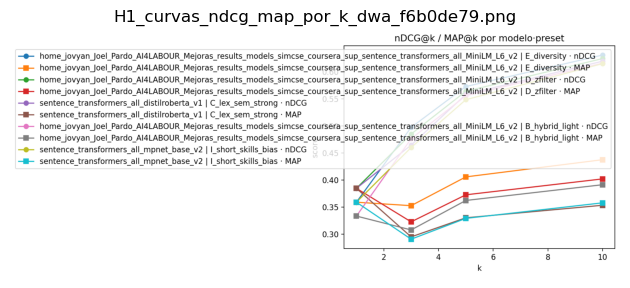


(20) [dwa] H1 — H1_curvas_prf_por_k_dwa_2d37603c.png


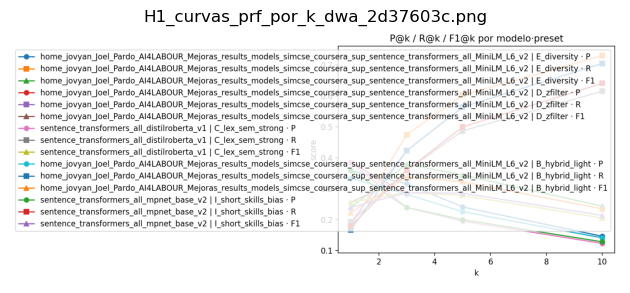


(21) [dwa] H1 — H1_map10_barh_e93d49aa.svg


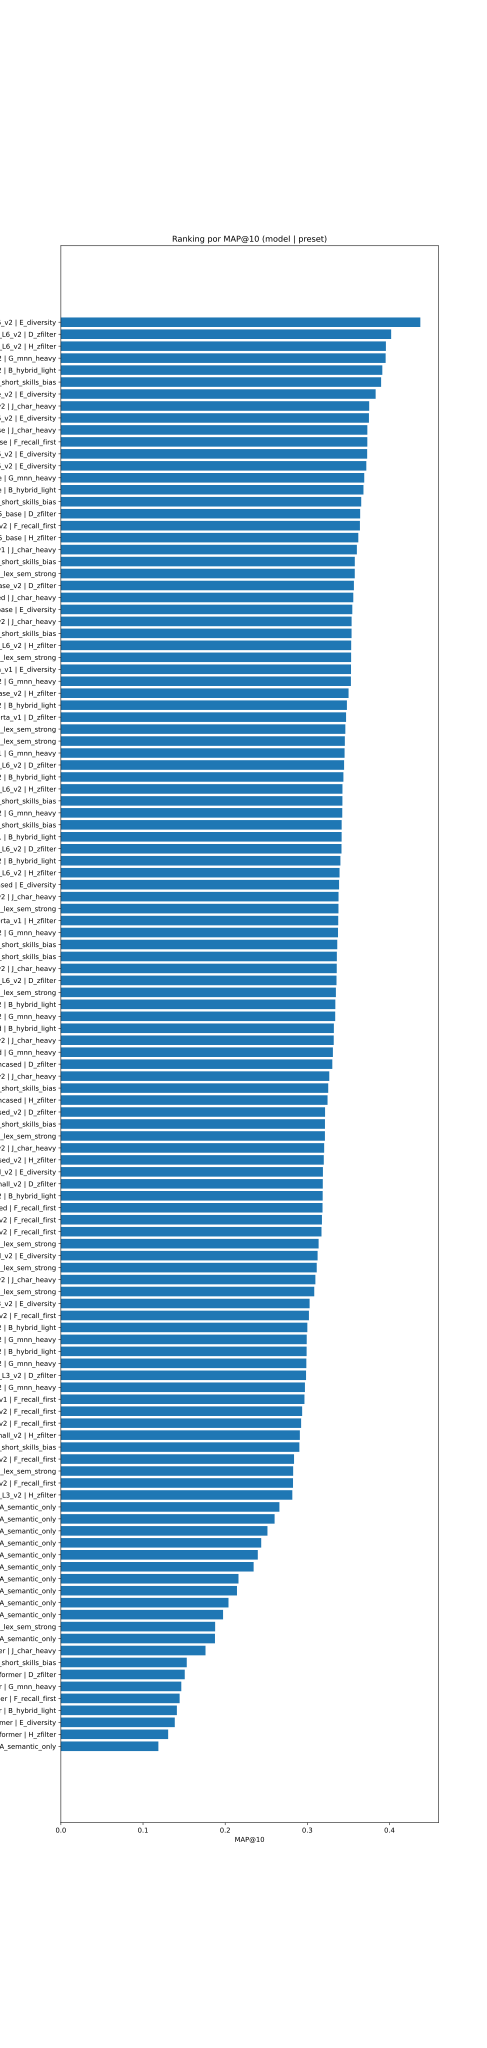


(22) [dwa] H1 — H1_ndcg10_barh_5c441837.svg


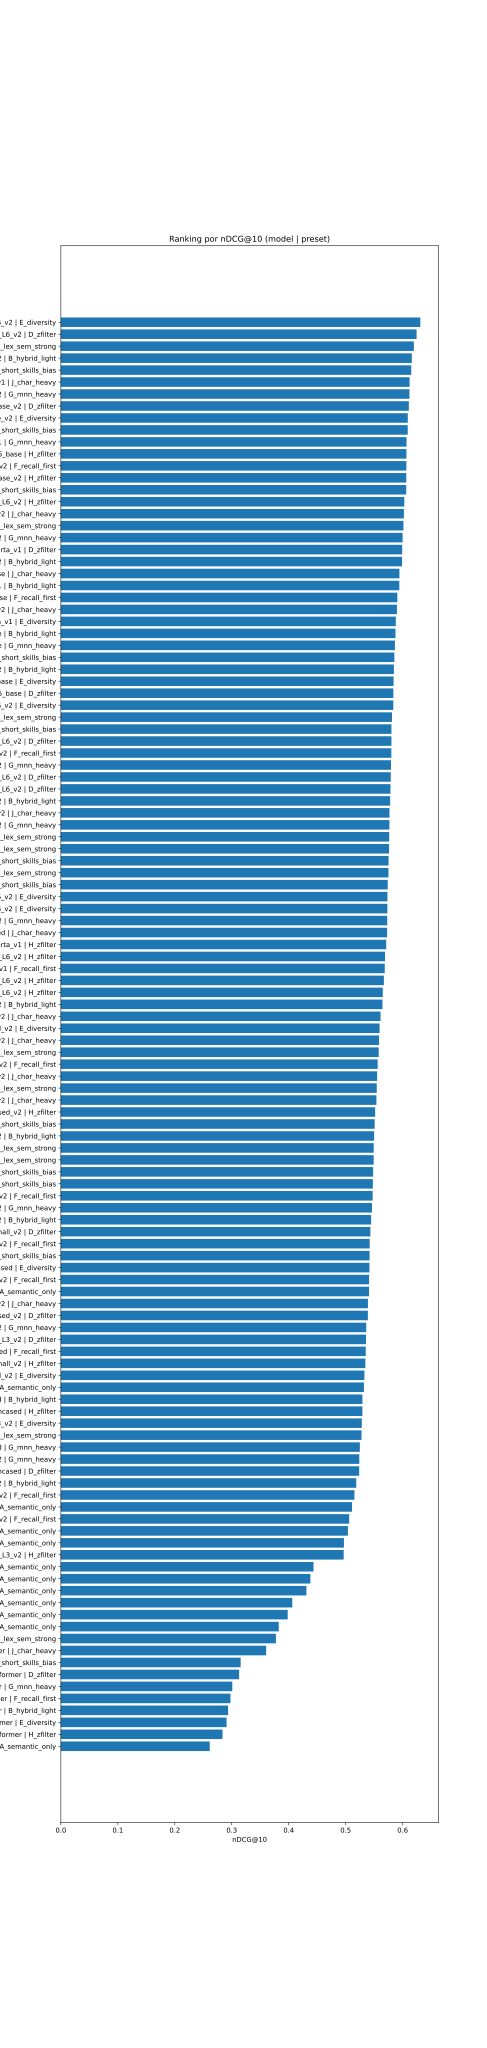


(23) [dwa] H2 — H2_threshold_curves_winner_a45f4ba2.svg


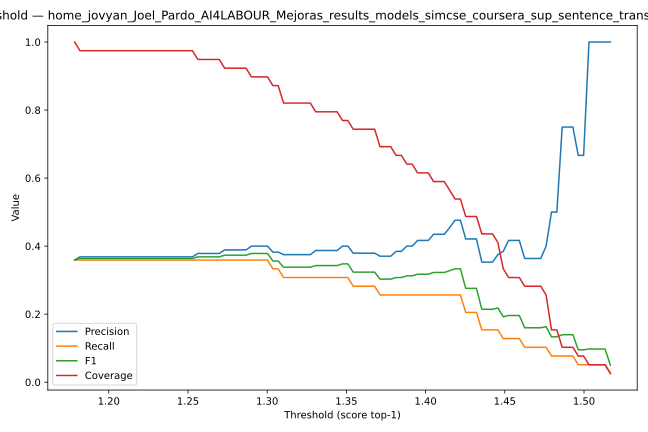


(24) [dwa] H2 — H2_winner_sweep_thr_coverage_dwa_b9e1a2f8.png


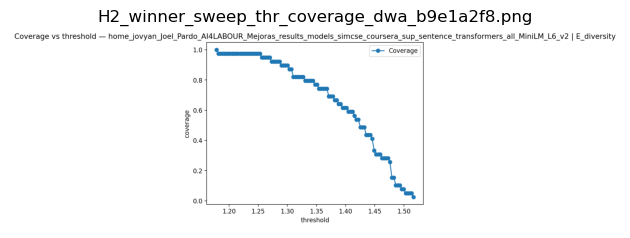


(25) [dwa] H2 — H2_winner_sweep_thr_prf_dwa_6d739094.png


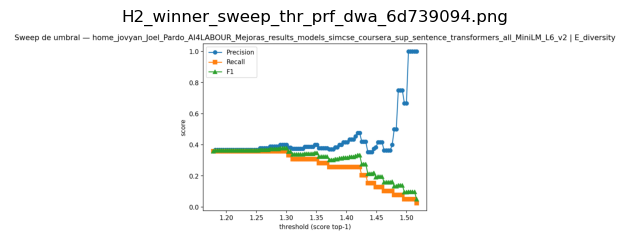


(26) [dwa] H3 — H3_score_hist_tp_fp_b25d1ba6.svg


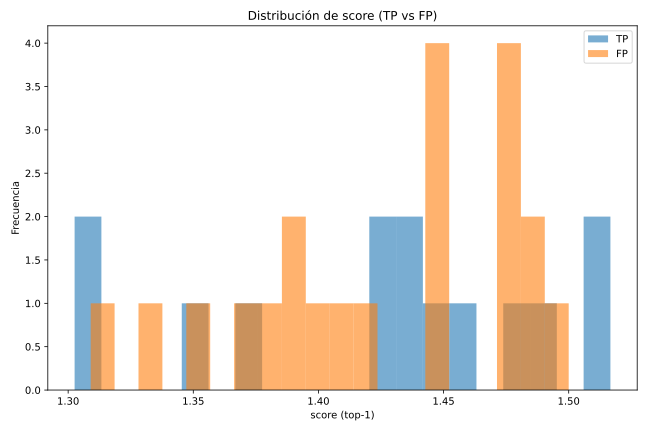

KeyboardInterrupt: 

In [42]:
from time import sleep

n_total = len(df)
if MAX_SHOW is not None:
    df = df.head(int(MAX_SHOW))

print(f"Mostrando {len(df)} de {n_total} imágenes (filtros: pipeline={PIPELINE_FILTER}, plot={PLOT_FILTER})")
for i, row in df.iterrows():
    p = row["dst_path"]
    title = f"[{row['pipeline']}] {row['plot_type']} — {os.path.basename(p)}"
    print(f"\n({i+1}) {title}")
    if row["ext"].lower() == "svg":
        show_svg(p)
        sleep(2)
    else:
        show_png(p)
        sleep(2)


## Coursera

In [ ]:
# VISUALIZADOR DE GRÁFICOS (desde plots_inspection)
# Filtros opcionales
PIPELINE_FILTER = "coursera"      # "dwa" | "coursera" | None
PLOT_FILTER     = None      # "H1" .. "H6" | "unknown" | None
MAX_SHOW        = 48        # None = sin límite


In [ ]:


# cargar inventario consolidado ya generado en la celda anterior
inv_dir = os.path.join(path_guardado, "plots_inspection", "inventories")
inv_all = pd.read_csv(os.path.join(inv_dir, f"inventory_images_ALL{experiment}.csv"))

df = inv_all.copy()
if PIPELINE_FILTER:
    df = df[df["pipeline"] == PIPELINE_FILTER.lower()]
if PLOT_FILTER:
    df = df[df["plot_type"].str.upper() == PLOT_FILTER.upper()]


In [ ]:
from time import sleep

n_total = len(df)
if MAX_SHOW is not None:
    df = df.head(int(MAX_SHOW))

print(f"Mostrando {len(df)} de {n_total} imágenes (filtros: pipeline={PIPELINE_FILTER}, plot={PLOT_FILTER})")
for i, row in df.iterrows():
    p = row["dst_path"]
    title = f"[{row['pipeline']}] {row['plot_type']} — {os.path.basename(p)}"
    print(f"\n({i+1}) {title}")
    if row["ext"].lower() == "svg":
        show_svg(p)
        sleep(2)
    else:
        show_png(p)
        sleep(2)
